<a href="https://colab.research.google.com/github/andiarenaleandro-ux/ISSD_PH/blob/main/ANDIARENA_LEANDRO_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping


**Andiarena Leandro**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


### 1.1 - Importacion de librerias

In [ ]:
!pip install spacy wordcloud --quiet
!python -m spacy download es_core_news_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 71.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import requests
from requests.exceptions import HTTPError
from bs4 import BeautifulSoup
import spacy
from spacy.lang.es.stop_words import STOP_WORDS
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
from collections import Counter


### 1.2 - WebScraping

In [ ]:
# url sobre la cual se va a trabajar
url = "https://www.infobae.com/tendencias/2026/02/03/ser-memorable-en-entrevistas-manejar-errores-y-saber-cuando-arriesgar-las-claves-de-patricia-jebsen-para-triunfar-en-el-trabajo/"

# Encabezados
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
    "Accept-Language": "es-AR,es;q=0.9,en;q=0.8",
    "Accept-Encoding": "gzip, deflate, br",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1",
}

In [ ]:
# Se extrae el HTML del url definido
try:
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    print("Éxito:", response.status_code)
except HTTPError as e:
    print(f"Error HTTP: {e.response.status_code}")
    raise



Éxito: 200


In [ ]:
# Se parsea HTML con BeautifulSoup y se extrae el contenido
soup = BeautifulSoup(response.text, "lxml")

contenedor = soup.find("div", class_="body-article")
parrafos = soup.select("div.body-article p.paragraph")

if not parrafos:
    texto = ""
else:
    texto = "\n".join(p.get_text(separator=" ", strip=True) for p in parrafos)

# Se verifica longitud del texto y cantidad de parrafos
print(len(texto))
print(len(parrafos))

28269
55


In [ ]:
# Se verifican los primeros caracteres y ultimos para evaluar estado del texto
print("\nPRIMEROS 500")
print(texto[:500])
print("\nÚLTIMOS 500")
print(texto[-500:])


PRIMEROS 500
En un nuevo episodio de La Fórmula Podcast , la empresaria y creadora de contenido Patricia Jebsen presentó su libro Pensar diferente y repasó su recorrido profesional: más de 30 años en el mundo corporativo, su rol clave en el desarrollo del e-commerce en Argentina y la decisión de reinventarse para dedicarse a los directorios de empresas, la divulgación en redes y el acompañamiento de quienes buscan crecer en el mundo laboral.
Durante la charla, compartió herramientas para construir una carrer

ÚLTIMOS 500
ella encima es una pasión, despierta una vocación o simplemente un poco de coraje para seguir, entonces nuestras palabras habrán cumplido su misión” . O sea, hagamos lo que hagamos en redes, escribiendo un libro, liderando equipos, en la empresa, dejémosle algo al otro. Si nosotros lo hacemos por el otro, es mucho mejor lo que vuelve. No seamos egoístas, porque muchas veces en la vida lo somos. Realmente, estemos todo el tiempo pensando cómo ayudamos a los demás y eso

In [ ]:
# Se verifica texto completo
print(texto)

En un nuevo episodio de La Fórmula Podcast , la empresaria y creadora de contenido Patricia Jebsen presentó su libro Pensar diferente y repasó su recorrido profesional: más de 30 años en el mundo corporativo, su rol clave en el desarrollo del e-commerce en Argentina y la decisión de reinventarse para dedicarse a los directorios de empresas, la divulgación en redes y el acompañamiento de quienes buscan crecer en el mundo laboral.
Durante la charla, compartió herramientas para construir una carrera con propósito, animarse a los cambios y tomar decisiones propias, incluso cuando implican salir de la zona de confort. Además, reflexionó sobre cómo encarar entrevistas de trabajo, la importancia de combinar habilidades técnicas y blandas y el rol del liderazgo y el bienestar en las nuevas generaciones. También habló del espíritu emprendedor , el armado de equipos diversos y la inteligencia artificial como competencia clave para el futuro. El episodio completo se puede escuchar en Spotify y Yo

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

Se identifican las stopwords que son aquellas palabras que suelen aparecer en casi todos los textos y no aportan significado util por si solas generando ruido a los modelos.

Uso spaCy en lugar de NLTK porque me da todo el procesamiento en un solo paso: al ejecutar `nlp(texto)` obtengo tokens, lemas, stopwords y categorías gramaticales ya calculados, sin pipelines manuales. Además, spaCy trae modelos entrenados por idioma que detectan stopwords y lematizan con contexto real, mientras que NLTK requiere descargar listas y lematizadores por separado y suele lematizar peor en español. También es mucho más rápido en volúmenes grandes de texto y su API es más limpia, así que para limpieza y análisis como este resulta más directo y confiable.

In [ ]:
# Se instancia el modelo en español
nlp = spacy.load("es_core_news_sm")

# Se procesa el texto extraido - Se crea el objeto doc con tokens
doc = nlp(texto)

stopwords_texto =  [token.text.lower() for token in doc if token.is_stop
                    and not token.is_punct  # Filtra puntuacion
                    and not token.is_space  # Filtra espacios
                    ]

conteo_stops = Counter(stopwords_texto)

print(f"Total de stopwords en el texto: {len(stopwords_texto)}")
print(f"Stopwords únicas: {len(conteo_stops)}")
print(f"\nTop 10 más frecuentes:")
for palabra, freq in conteo_stops.most_common(10):
    print(f"  {palabra:15} → {freq} veces")

total_tokens = len([t for t in doc if not t.is_punct and not t.is_space])
print(f"\nPorcentaje de stopwords: {len(stopwords_texto)/total_tokens*100:.1f}%")

Total de stopwords en el texto: 3283
Stopwords únicas: 267

Top 10 más frecuentes:
  que             → 333 veces
  de              → 145 veces
  y               → 143 veces
  en              → 122 veces
  a               → 113 veces
  es              → 111 veces
  no              → 102 veces
  la              → 94 veces
  el              → 80 veces
  lo              → 80 veces

Porcentaje de stopwords: 65.2%


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

Lematizo para unificar variantes de una misma palabra, elimino stopwords porque no aportan significado, descarto puntuación y espacios por ser ruido, dejo solo tokens alfabéticos de más de tres letras para evitar números y palabras vacías, y paso todo a minúsculas para no duplicar términos.

In [ ]:
ruido_conversacional = {"cosa", "tipo", "bueno", "medio", "tema", "él"}


# Se filtra solo los tokens que no son Stopwords
lemas = [token.lemma_.lower() for token in doc
                if not token.is_stop
                and token.lemma_.lower() not in STOP_WORDS
                and token.lemma_.lower() not in ruido_conversacional
                and not token.is_punct        # quita puntuación
                and not token.is_space        # quita espacios/saltos
                and token.text.strip()        # evita tokens vacíos
                and token.is_alpha            # Solo palabras alfabeticas
                and len(token.text) > 3       # filtrado palabras cortas
                ]

# Texto limpio
texto_limpio = " ".join(lemas)

print(texto_limpio)

episodio fórmula podcast empresario creador contenido patricia jebsen presentar libro pensar repasar recorrido profesional año mundo corporativo clave desarrollo argentina decisión reinventar él dedicar él directorio empresa divulgación red acompañamiento buscar crecer mundo laboral charla compartir herramienta construir carrera propósito animar él cambio tomar decisión implicar salir zona confort reflexionar encarar entrevista trabajo importancia combinar habilidad técnico blando liderazgo bienestar generación hablar espíritu emprendedor armado equipo diverso inteligencia artificial competencia clave futuro episodio completo escuchar spotify youtube patricia jebsen destacada ejecutivo consultora argentino año trayectoria mundo corporativo especialmente comercio electrónico omnicanalidad transformación digital licenciado relaciones públicas uade maestría marketing administración empresas european business school alemania comunicación corporativa prensa uces programa ejecutivo universid

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",        # paleta de colores
    max_words=100,
).generate(texto_limpio)       # texto_limpio es tu string de lemas unidos

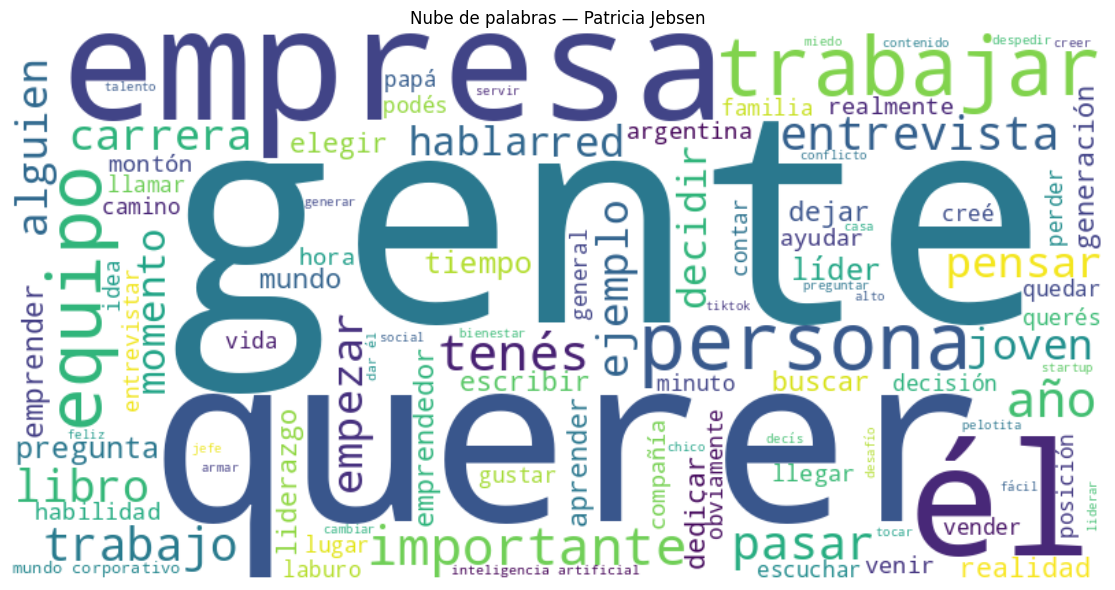

In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — Patricia Jebsen")
plt.tight_layout()
plt.show()

Las palabras más prominentes reflejan los ejes centrales de la entrevista: el foco en las personas (gente, persona, equipo), la acción profesional (trabajar, empresa, carrera, emprender) y la actitud ante la vida laboral (querer, decidir, pensar). Esto confirma que el preprocesamiento logró separar el contenido semántico del ruido.

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


**Documento:** cada oración limpia es un documento; el vectorizador trata cada string de la lista como una unidad independiente.

**Limpieza:** quito stopwords (no distinguen oraciones), puntuación y espacios (no son palabras), números y tokens cortos (ruido), lematizo (unifico variantes) y paso a minúsculas (evito duplicados).

**Matriz documento-vocabulario:** tabla donde cada fila es una oración, cada columna una palabra del vocabulario y cada celda el conteo de esa palabra en esa oración. Es texto convertido a números; como casi todo es 0, se guarda como matriz dispersa (solo los valores no-cero para ahorrar memoria).

In [ ]:
oraciones_limpias = []

# Palabras que no son stopwords técnicas pero son ruido conversacional
ruido = {"cosa", "él", "vo"}

# limpiar y lematizar tokens de la oración
for sent in doc.sents:
  lemas = [
      token.lemma_.lower()
      for token in sent
      if not token.is_stop
      and token.lemma_.lower() not in ruido
      and not token.is_punct
      and not token.is_space
      and token.is_alpha
      and len(token.text) > 3
      and token.lemma_.lower() not in STOP_WORDS
  ]
  # descartar oraciones con menos de 3 tokens útiles
  if len(lemas) < 3:
      continue

  # reconstruir como string
  oracion = " ".join(lemas)

  # descartar si quedó vacía
  if not oracion.strip():
      continue

  oraciones_limpias.append(oracion)

print(oraciones_limpias)

['episodio fórmula podcast empresario creador contenido patricia jebsen presentar libro pensar repasar recorrido profesional año mundo corporativo clave desarrollo argentina decisión reinventar él dedicar él directorio empresa divulgación red acompañamiento buscar crecer mundo laboral', 'charla compartir herramienta construir carrera propósito animar él cambio tomar decisión implicar salir zona confort', 'reflexionar encarar entrevista trabajo importancia combinar habilidad técnico blando liderazgo bienestar generación', 'hablar espíritu emprendedor armado equipo diverso inteligencia artificial competencia clave futuro', 'episodio completo escuchar spotify youtube', 'patricia jebsen destacada ejecutivo consultora argentino año trayectoria mundo corporativo especialmente comercio electrónico omnicanalidad transformación digital', 'licenciado relaciones públicas uade maestría marketing administración empresas european business school alemania comunicación corporativa prensa uces programa

In [ ]:
vectorizer = CountVectorizer()
matriz = vectorizer.fit_transform(oraciones_limpias)

In [ ]:
print("Shape:", matriz.shape)
print("Términos:", vectorizer.get_feature_names_out()[:10])

Shape: (228, 652)
Términos: ['abarcar' 'abrir' 'acabar' 'acabas' 'acceso' 'acción' 'acompañamiento'
 'acordar' 'actitud' 'activo']



#### 2.3.2 Determina la longitud de tu vocabulario.

In [ ]:
vocabulario = vectorizer.get_feature_names_out()

print("Longitud del vocabulario:", len(vocabulario))
print("Primeras 10:", vocabulario[:10])
print("Últimas 10:", vocabulario[-10:])

Longitud del vocabulario: 652
Primeras 10: ['abarcar' 'abrir' 'acabar' 'acabas' 'acceso' 'acción' 'acompañamiento'
 'acordar' 'actitud' 'activo']
Últimas 10: ['vivís' 'vocación' 'volver' 'vuelta' 'yo' 'youtube' 'zona' 'ándate'
 'área' 'él']



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [ ]:
# Aplicar TF-IDF
tfidf = TfidfVectorizer()
matriz_tfidf = tfidf.fit_transform(oraciones_limpias)

# Shape
print("Shape:", matriz_tfidf.shape)

Shape: (228, 652)


In [ ]:
# Convertir a DataFrame
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

In [ ]:
# Palabras con mayor score TF-IDF promedio
scores_promedio = df_tfidf.mean(axis=0).sort_values(ascending=False)
print(scores_promedio.head(15))

querer        0.035010
gente         0.033230
trabajar      0.027797
empresa       0.027185
persona       0.025052
él            0.024819
equipo        0.022384
tenés         0.021887
importante    0.020837
año           0.019957
pensar        0.019002
mundo         0.017656
libro         0.016443
trabajo       0.016308
joven         0.015614
dtype: float64


In [ ]:
# Elegir una oración
idx = 20
print(f"Oración: {oraciones_limpias[idx]}")
print(f"\nTop 5 palabras TF-IDF:")
print(df_tfidf.iloc[idx].sort_values(ascending=False).head(5))

Oración: realidad estudié relación público

Top 5 palabras TF-IDF:
relación    0.539237
estudié     0.539237
público     0.501150
realidad    0.409017
obtener     0.000000
Name: 20, dtype: float64


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

Formato de la matriz resultante

Tamaño: (238, 673) → matriz dispersa de 238 filas × 673 columnas.

Documentos (filas): 238 oraciones extraídas del texto con doc.sents y filtradas por tener al menos 3 tokens útiles. Cada oración se trata como un documento independiente.

Vocabulario (columnas): 673 palabras únicas obtenidas tras aplicar lowercase, lematización y remoción de stopwords, puntuación, espacios, no-alfabéticos y tokens ≤ 3 caracteres.

Contenido de cada celda [i, j]: score TF-IDF de la palabra j en la oración i. Valor alto = la palabra es frecuente en esa oración pero rara en el corpus general (distintiva). Valor cero = la palabra no aparece en esa oración.


Las palabras con mayor TF-IDF promedio (querer, gente, trabajar, empresa, persona, equipo) reflejan los ejes centrales del discurso de Patricia Jebsen: personas, acción profesional y actitud ante el trabajo.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

Este TP me sirvio para poder recorrer un pipeline completo de NLP sobre un texto real: scraping → limpieza → vectorización → análisis.

A priori se observa como la calidad del análisis depende del preprocesamiento. Es decir filtrar bien las stopwords, lematizar, quitar ruido conversacional y separar en oraciones es lo principal para que el metodo TF-IDF resaltara palabras significativas ("querer", "gente", "trabajar", "empresa", "liderazgo") en lugar de ruido gramatical.

Comprobé segun la teoria, por qué spaCy es hoy el estándar para NLP en español frente a NLTK — API integrada, lematización de calidad y filtros por atributos que hacen el código más limpio y menos propenso a errores.


Este TP me deja las bases del pipeline NLP clásico armadas. Me permite tener herramientas para tomar decisiones sobre limpieza y vectorización, y con conciencia de las limitaciones (modelos chicos, ruido conversacional, etc) que siempre hay que evaluar en un caso real.